#Logistic Regression

Implementing a standard Logistic Regression model to test for linear separability in our feature space.

In [ ]:
import os
import pickle

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from metrics_utils import calculate_business_metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

load_dotenv()

mlflow.set_experiment("Walmart-Sales-Classification")
mlflow.set_tracking_uri("https://dagshub.com/sarah-kamall/walmart-sales-classification.mlflow")

<Experiment: artifact_location='file:///home/shehab/tmp/walmart-sales-classification/src/models/mlruns/401607475239176337', creation_time=1777790507939, experiment_id='401607475239176337', last_update_time=1777790507939, lifecycle_stage='active', name='Walmart-Sales-Classification', tags={}>

In [2]:
train_df = pd.read_csv("../../data/model_ready/train.csv")
test_df = pd.read_csv("../../data/model_ready/test.csv")

features_selected = [
    "Size",
    "Store",
    "Dept",
    "CPI",
    "DeptFrequency",
    "Week_cos",
    "IsPreHoliday",
    "Week_sin",
    "Fuel_Price",
    "ConsumerConfRatio",
    "AvgMarkDownAmount",
]
target = "Sales_Class"
holiday_col = "IsHoliday"

X_train = train_df[features_selected]
y_train = train_df[target]
X_test = test_df[features_selected]
y_test = test_df[target]
test_holidays = test_df[holiday_col]

In [3]:
with mlflow.start_run(run_name="Logistic_Regression"):
    model_path = "logreg_model.pkl"
    if os.path.exists(model_path):
        with open(model_path, "rb") as f:
            model = pickle.load(f)
            print("Model loaded from pickle")
    else:
        model = LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        with open(model_path, "wb") as f:
            pickle.dump(model, f)
        print("Model trained and saved to pickle")

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    biz_metrics = calculate_business_metrics(y_test, y_pred, test_holidays)

    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("C", 1.0)
    mlflow.log_param("max_iter", 1000)

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_weighted", f1)
    mlflow.log_metric("holiday_accuracy", biz_metrics["holiday_accuracy"])
    mlflow.log_metric("weighted_classification_error", biz_metrics["weighted_classification_error"])

    mlflow.log_artifact(model_path)

    mlflow.sklearn.log_model(model, artifact_path="model")

    print(f"Accuracy: {acc:.4f}")
    print(f"Holiday Accuracy: {biz_metrics['holiday_accuracy']:.4f}")
    print(f"Weighted Error: {biz_metrics['weighted_classification_error']:.4f}")

Model trained and saved to pickle


2026/05/03 11:11:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Accuracy: 0.6593
Holiday Accuracy: 0.6697
Weighted Error: 0.3321


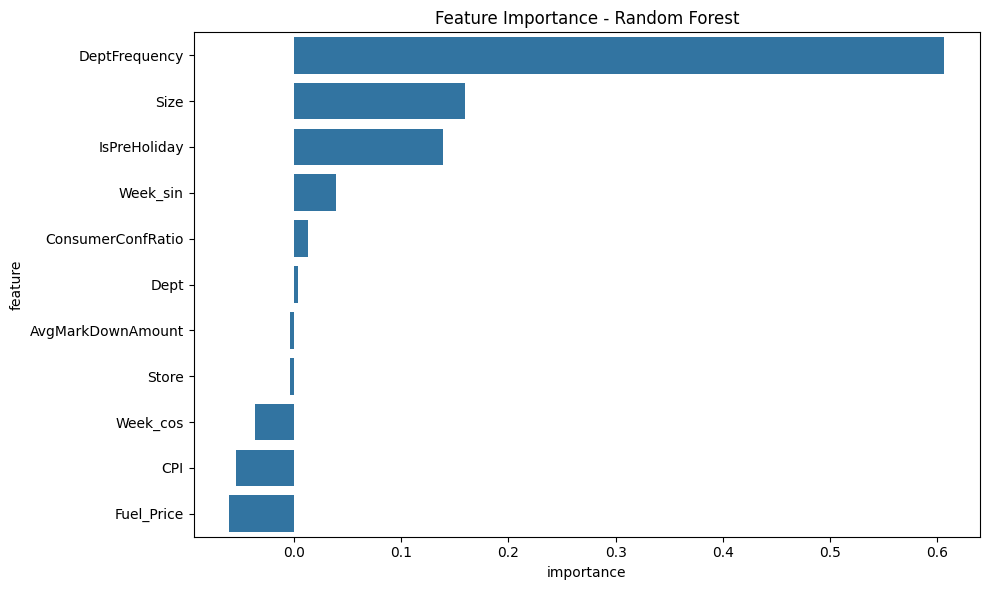

In [4]:
importances = model.coef_[0]
feature_names = features_selected
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feature_importance_df)
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png")
mlflow.log_artifact("feature_importance.png")
plt.show()